In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### DataLoading

In [2]:
df=pd.read_csv('../datasets/cars_data.csv')

In [3]:
df.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df.shape

(301, 9)

In [6]:
df.dtypes

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object

In [7]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [9]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

### Feature Engineering

In [10]:
df['car_age']=2025-df['Year']

In [15]:
df['KMs_per_year']=df['Driven_kms']/df['car_age']

In [18]:
df['KMs_per_year']=round(df['KMs_per_year'],2)

In [19]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,car_age,KMs_per_year
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11,2454.55
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12,3583.33
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8,862.50
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14,371.43
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11,3859.09


### Exploratory Data Analysis

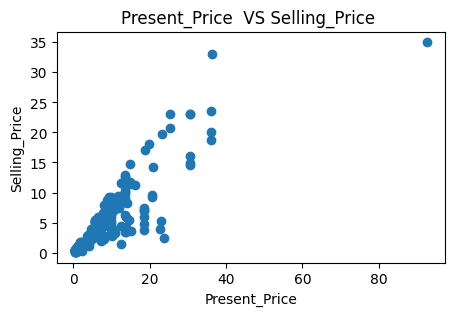

In [ ]:
plt.figure(figsize=(5,3))
plt.scatter(data=df,
            x='Present_Price',
            y='Selling_Price')
plt.xlabel("Present_Price")
plt.ylabel("Selling_Price")
plt.title("Present_Price  VS Selling_Price ")
plt.show()

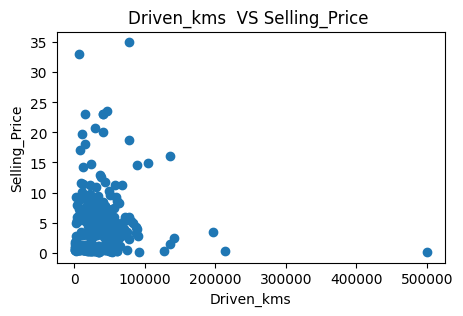

In [27]:
plt.figure(figsize=(5,3))
plt.scatter(data=df,
            x='Driven_kms',
            y='Selling_Price')
plt.xlabel("Driven_kms")
plt.ylabel("Selling_Price")
plt.title("Driven_kms  VS Selling_Price ")
plt.show()

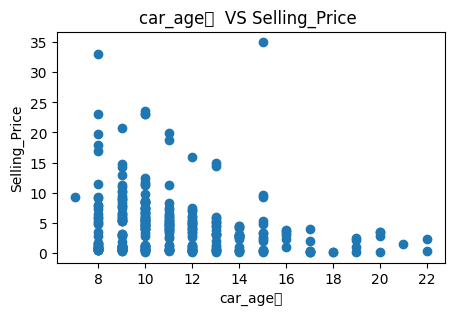

In [29]:
plt.figure(figsize=(5,3))
plt.scatter(data=df,
            x='car_age',
            y='Selling_Price')
plt.xlabel("car_age	")
plt.ylabel("Selling_Price")
plt.title("car_age	  VS Selling_Price ")
plt.show()

In [30]:
df['Fuel_Type'].value_counts()

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

In [31]:
df['Transmission'].value_counts()

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

In [33]:
df.corr(numeric_only=True)

,Year,Selling_Price,Present_Price,Driven_kms,Owner,car_age,KMs_per_year
Year,1.000000,0.236141,-0.047192,-0.524342,-0.182104,-1.000000,-0.346763
Selling_Price,0.236141,1.000000,0.878914,0.029187,-0.088344,-0.236141,0.134574
Present_Price,-0.047192,0.878914,1.000000,0.203618,0.008058,0.047192,0.260111
Driven_kms,-0.524342,0.029187,0.203618,1.000000,0.089216,0.524342,0.954140
Owner,-0.182104,-0.088344,0.008058,0.089216,1.000000,0.182104,0.036272
car_age,-1.000000,-0.236141,0.047192,0.524342,0.182104,1.000000,0.346763
KMs_per_year,-0.346763,0.134574,0.260111,0.954140,0.036272,0.346763,1.000000


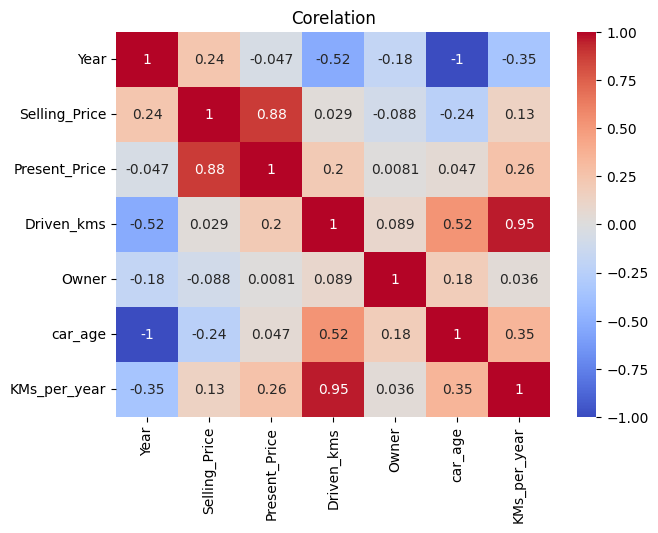

In [39]:
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Corelation")
plt.show()